<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# Orion-2: Multi-Schema Document Extraction

One agent execution. The `medical-multi-schema-extraction` skill **classifies the document, selects the matching schema, then extracts**, with grounding and confidence baked in.

| Step | What happens |
|---|---|
| **1. Classify** | Orion-2 labels the PDF as `referral`, `medical_record_request`, or `progress_note_office_visit` |
| **2. Select schema** | Loads **exactly one** schema from `schemas/<documentType>.json` |
| **3. Extract** | Runs `vlmrun.document.extract` with that schema, `grounding=True`, `confidence=True` |

You call `client.agent.execute` once. Schema selection is the skill's job. You do not pick the schema yourself.

We run a multi-document PDF that includes a CMS-1500 Medicare claim, patient insurance card, patient medical history, and handwritten physician referral. Expect `documentType="referral"` / `schemaUsed="referral"` and the referral schema to be selected automatically.

**Docs:** [Code Execution](https://docs.vlm.run/agents/code-execution), [Executions](https://docs.vlm.run/skills/usage/agent)


---
## ⚙️ 1. Setup

Install the VLM Run SDK, plus `pypdfium2` (used by the SDK's `pdf_images` helper to render the pages).


In [1]:
!pip install vlmrun --upgrade --quiet
!pip install pypdfium2 --quiet
!pip install pandas --quiet


## 🔑 2. Load your API key

Add your `VLMRUN_API_KEY` to the Colab **Secrets** tab (🔑 icon, left sidebar), then load it below.


In [2]:
import os

try:
    from google.colab import userdata
    VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")
except (ImportError, Exception):
    import getpass
    VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY") or getpass.getpass("Enter your VLM Run API key: ")

assert VLMRUN_API_KEY, "Missing VLMRUN_API_KEY in environment or Colab Secrets."
print("✅ API key loaded")


✅ API key loaded


## 🧩 3. The multi-schema skill

Point at `medical-multi-schema-extraction`. Grounding and confidence live inside the skill pipeline. After it **selects** the schema for the detected document type, it extracts with `grounding=True` and `confidence=True`.

Uses the pinned skill version below. Update `skill_version` if you publish a newer revision.


In [3]:
from vlmrun.client.types import AgentSkill

SKILL = AgentSkill(
    skill_name="medical-multi-schema-extraction",
    skill_version="20260722-5d4d2e43",
)

print("Skill:", SKILL.skill_name, SKILL.skill_version)
print("Schemas the skill can select:")
print("  • referral")
print("  • medical_record_request")
print("  • progress_note_office_visit")


Skill: medical-multi-schema-extraction 20260722-5d4d2e43
Schemas the skill can select:
  • referral
  • medical_record_request
  • progress_note_office_visit


## 📄 4. The multi-document PDF

Download the PDF and preview every page. We don't assume page layout up front. Even though this multi-document PDF mixes several form types, the skill should classify it as a referral and **select the referral schema**, not the record-request or progress-note schemas.


In [4]:
#@title Display helpers { display-mode: "form" }
import base64, requests
from io import BytesIO
from pathlib import Path
from IPython.display import HTML, display
from vlmrun.common.pdf import pdf_images  # SDK helper (pypdfium2 under the hood)


def show_image(img, caption="", width=560):
    """Show a PIL image inline, capped at `width` px so it fits nicely in Colab."""
    buf = BytesIO()
    img.convert("RGB").save(buf, format="JPEG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    tag = (f"<img src='data:image/jpeg;base64,{b64}' "
           f"style='max-width:{width}px; border:1px solid #eee; border-radius:6px'>")
    if caption:
        tag = (f"<div style='text-align:center'>{tag}"
               f"<div style='font-size:12px; color:#666; margin-top:4px'>{caption}</div></div>")
    display(HTML(tag))


def show_images_grid(items, width=240):
    """Render a list of (PIL image, caption) tuples as a responsive grid (cookbook-style)."""
    html = "<div style='display:flex; flex-wrap:wrap; gap:14px; align-items:flex-start'>"
    for img, caption in items:
        buf = BytesIO()
        img.convert("RGB").save(buf, format="JPEG", quality=85)
        b64 = base64.b64encode(buf.getvalue()).decode()
        html += (
            f"<div style='text-align:center; width:{width}px'>"
            f"<img src='data:image/jpeg;base64,{b64}' "
            f"style='width:{width}px; border:1px solid #ddd; border-radius:6px'>"
            f"<div style='font-size:12px; color:#555; margin-top:6px'>{caption}</div>"
            "</div>"
        )
    html += "</div>"
    display(HTML(html))


print("Display helpers loaded.")


Display helpers loaded.


Downloaded multi-document.pdf | 5 page(s)



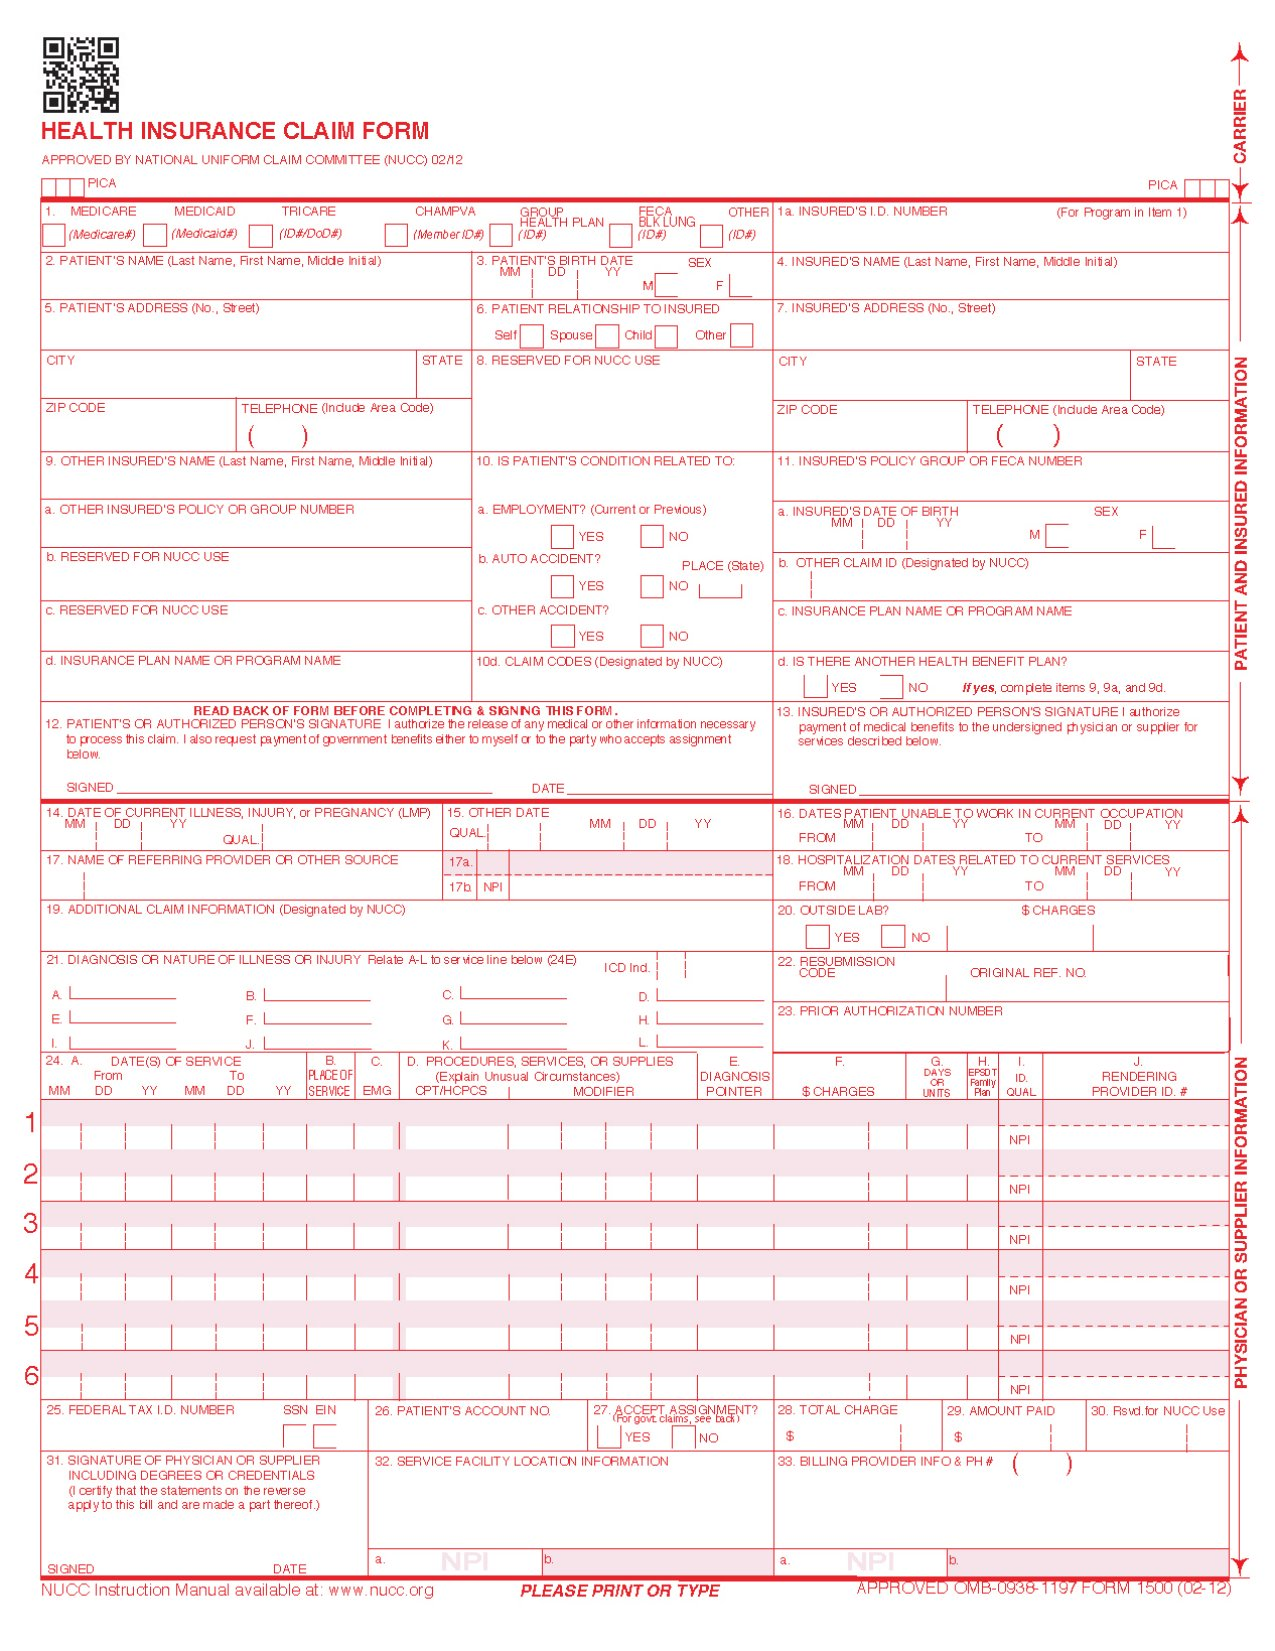
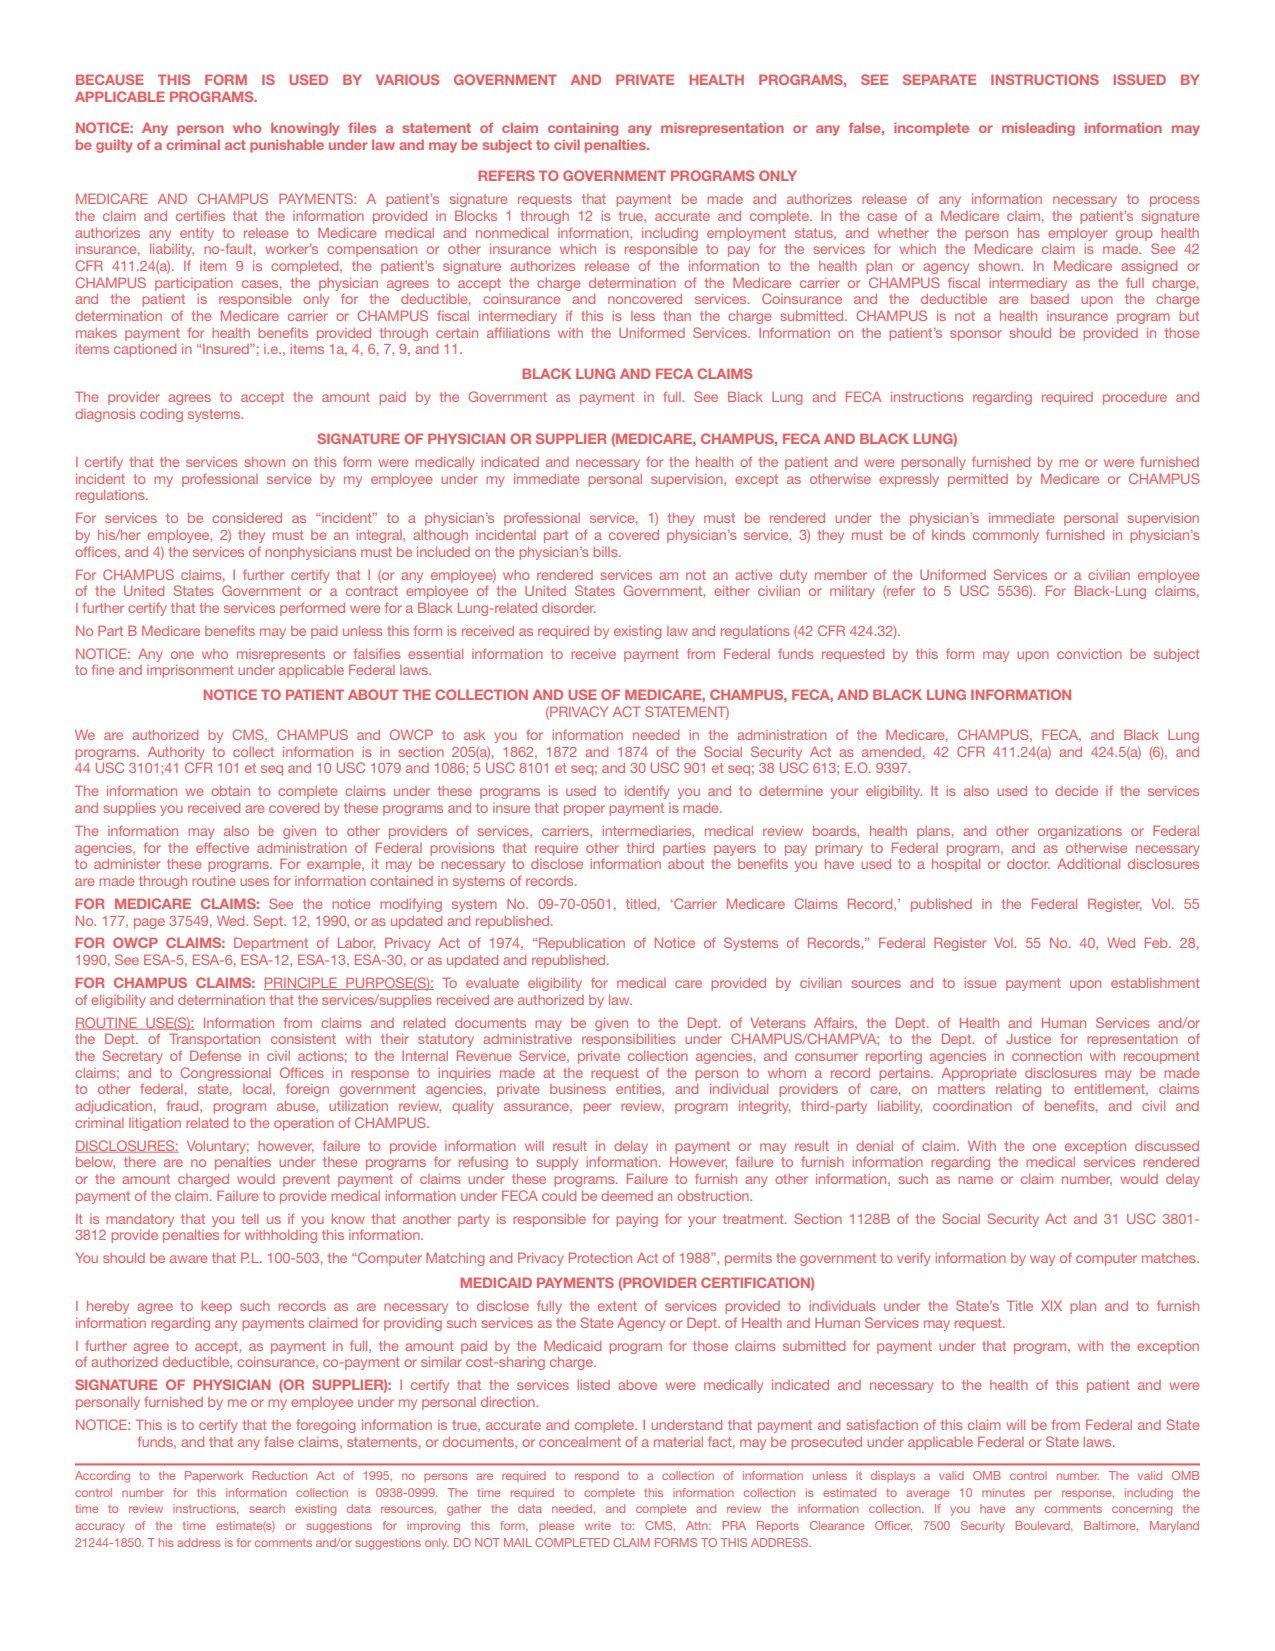
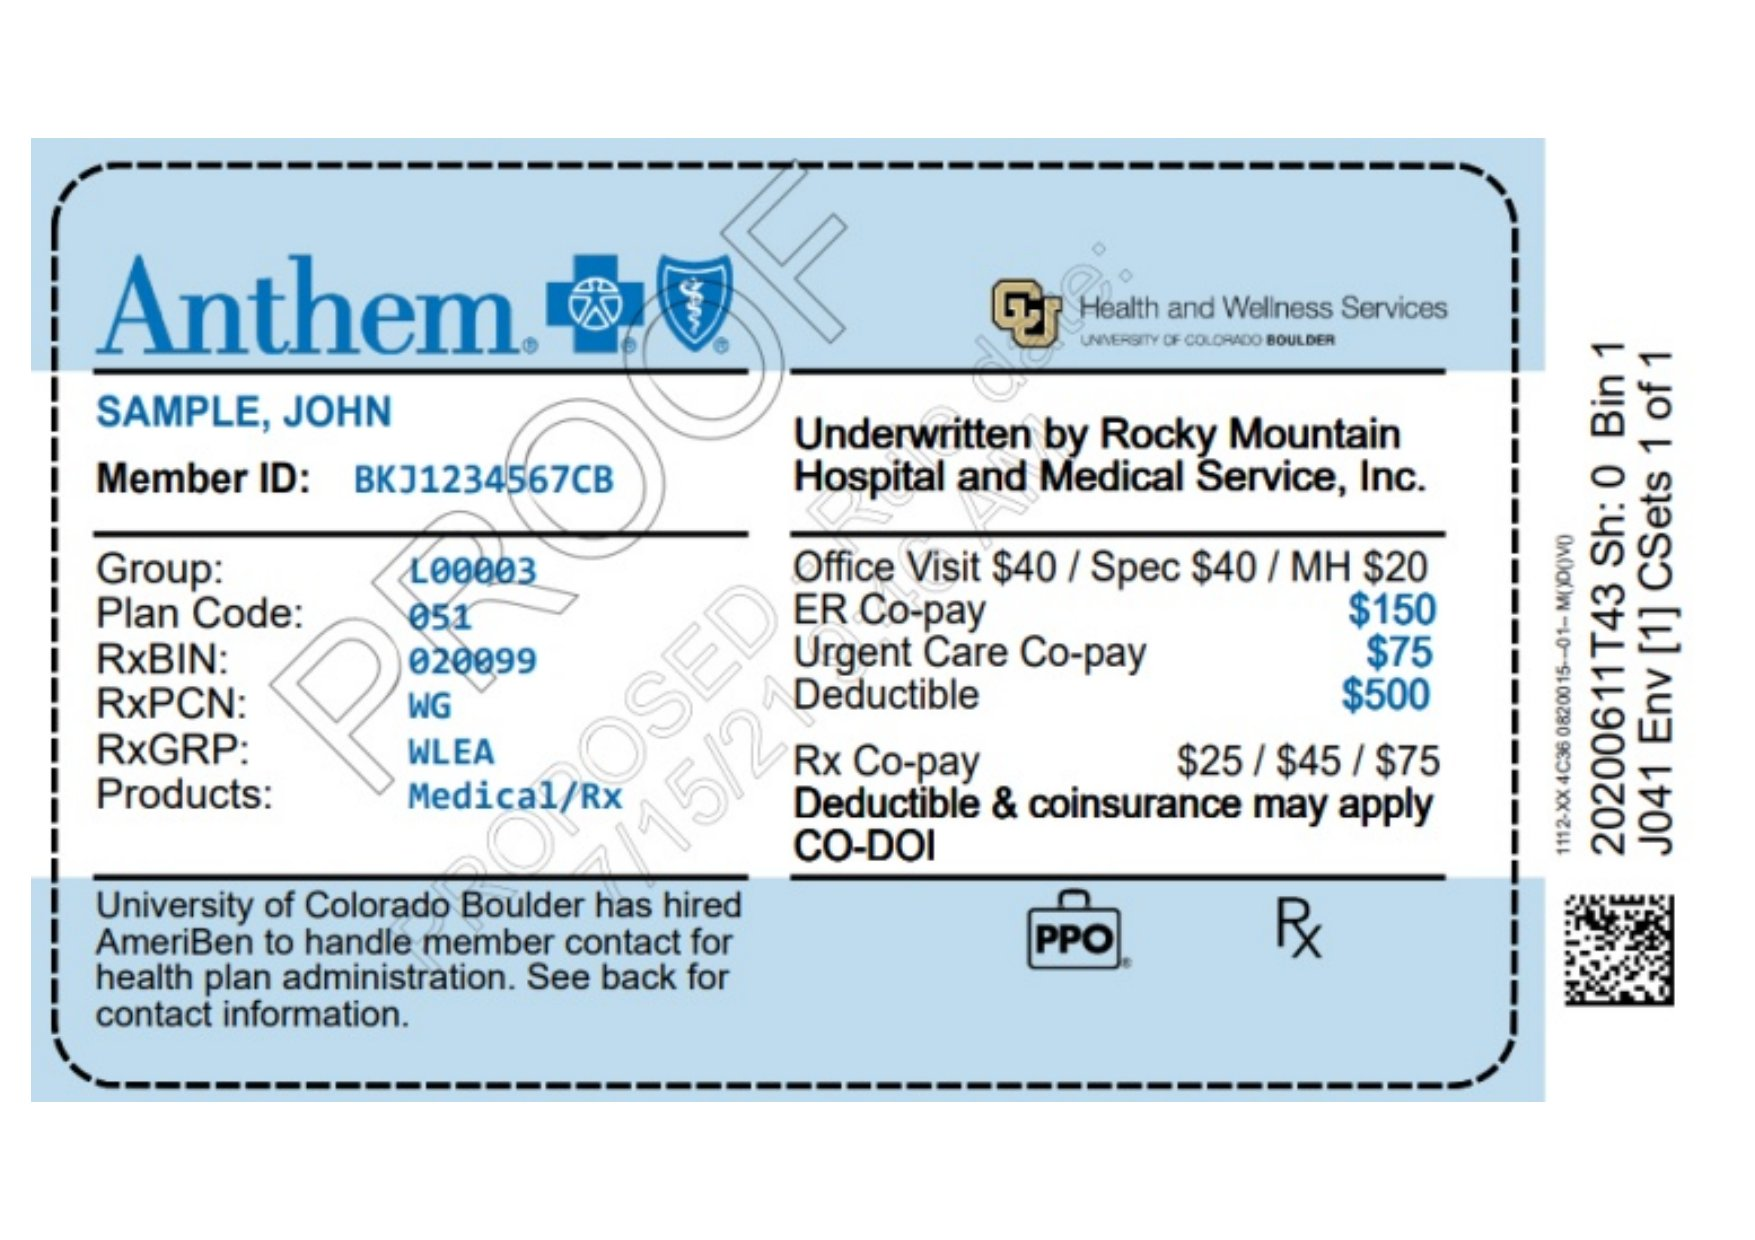
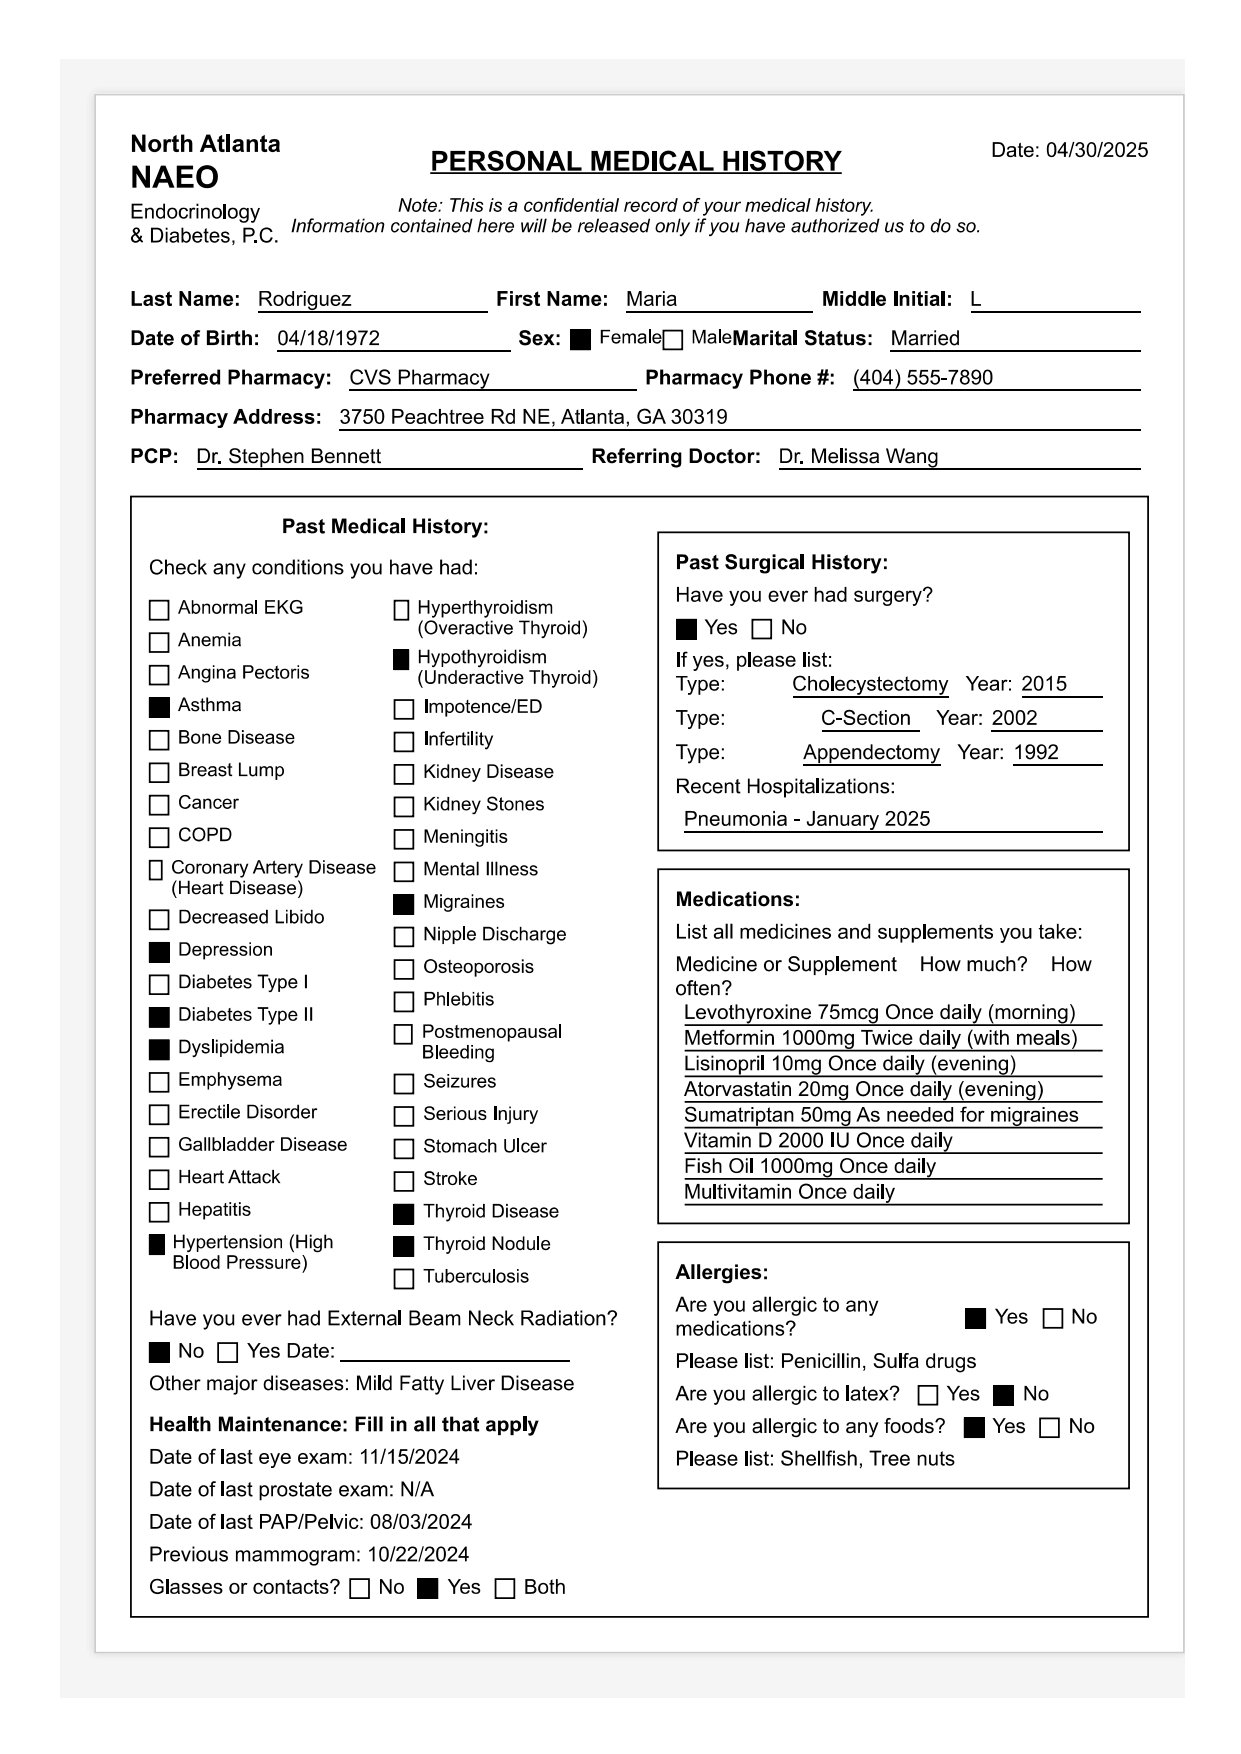
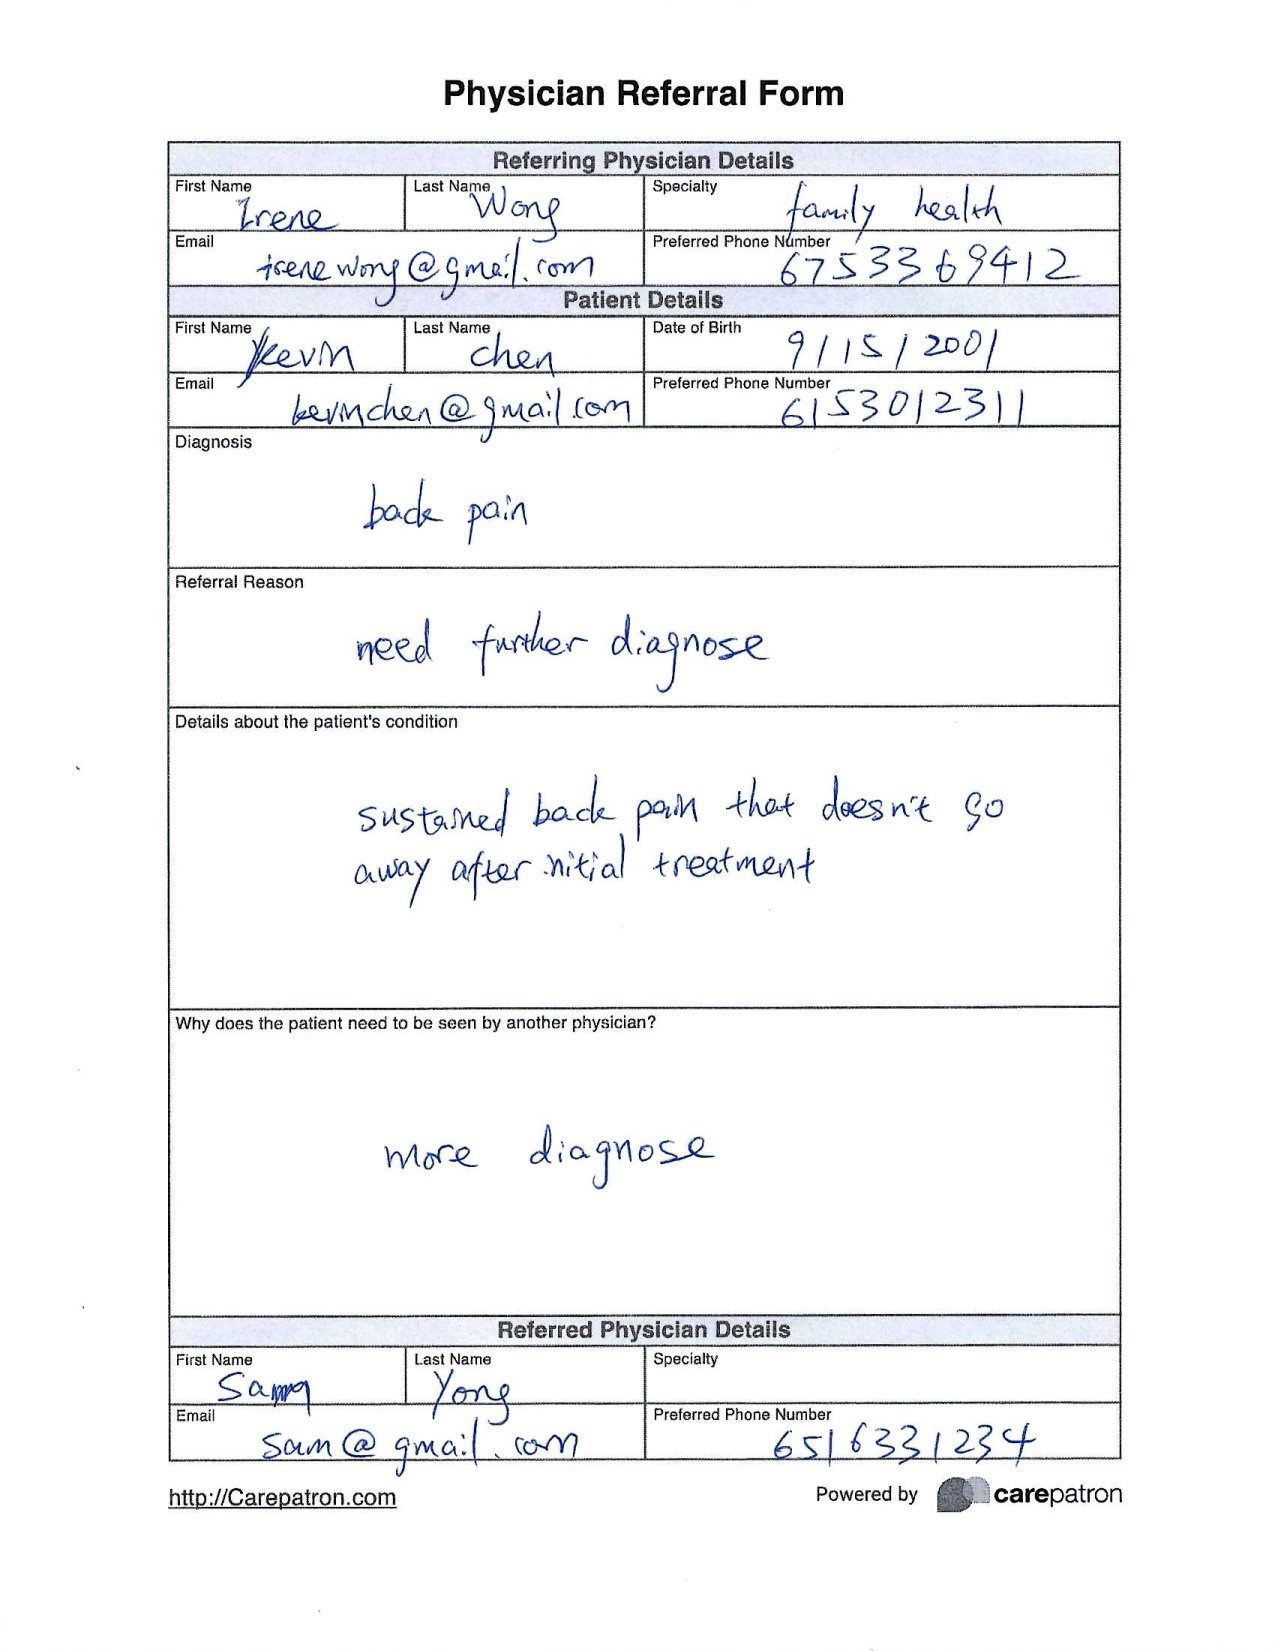

In [5]:
REFERRAL_URL = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-referral/multi-document.pdf"
PDF_PATH = Path("/content/multi-document.pdf")
PDF_PATH.write_bytes(requests.get(REFERRAL_URL).content)

pdf_pages = list(pdf_images(PDF_PATH, dpi=150))
print(f"Downloaded {PDF_PATH.name} | {len(pdf_pages)} page(s)")

# Preview the whole PDF (all pages), same idea as cookbook 16's input preview grid
previews = [
    (page.image, f"Page {page.page_number + 1}")
    for page in pdf_pages
]
show_images_grid(previews, width=300)


---
## ✨ 5. One execution: classify → select schema → extract

Create the client, upload the PDF, then call `client.agent.execute` once. The skill:

1. Classifies the document type
2. **Selects** `schemas/<documentType>.json`
3. Extracts with grounding + confidence

`executions.wait` blocks until it finishes.


In [6]:
from pydantic import BaseModel, Field
from vlmrun.client import VLMRun
from vlmrun.types import MessageContent
from vlmrun.client.types import AgentExecutionConfig, AgentExecutionResponse

client = VLMRun(api_key=VLMRUN_API_KEY)
print("✅ Client ready → api.vlm.run")


class FileInput(BaseModel):
    file: MessageContent = Field(..., description="The file to process")


uploaded_file = client.files.upload(file=PDF_PATH)
print(f"Uploaded file ID: {uploaded_file.id}")

execution: AgentExecutionResponse = client.agent.execute(
    model="vlmrun-orion-2:pro",
    inputs=FileInput(
        file=MessageContent(type="input_file", file_id=uploaded_file.id),
    ),
    config=AgentExecutionConfig(skills=[SKILL], mode="program"),
    batch=True,
)
print(f"Execution ID: {execution.id} | status: {execution.status}")


✅ Client ready → api.vlm.run
Uploaded file ID: 344524bb-1f66-473f-aaf3-17989bbde5a9
Execution ID: 13532f3f-9977-4ba9-abd1-c329bc8fb10e | status: enqueued


### 🧾 Wait & inspect: which schema was selected?

The skill returns something shaped like:

```json
{
  "schemaUsed": "referral",
  "documentType": "referral",
  "classificationRationale": "...",
  "data": { "pages": [ /* grounded extraction */ ] }
}
```

`documentType` is the classified type; `schemaUsed` identifies which schema was loaded (currently the same value as `documentType`, but can be distinct depending on the schema names).


In [7]:
#@title Schema-selection helpers { display-mode: "form" }
def _find(obj, *keys):
    """Walk a nested payload and return the first matching key."""
    if isinstance(obj, dict):
        for k in keys:
            if k in obj:
                return obj[k]
        for v in obj.values():
            found = _find(v, *keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _find(v, *keys)
            if found is not None:
                return found
    return None


print("Schema-selection helpers loaded.")


Schema-selection helpers loaded.


In [8]:
execution = client.executions.wait(execution.id, timeout=300)
print("✅ Status:", execution.status)

payload = execution.response or {}

document_type = _find(payload, "documentType")
schema_used = _find(payload, "schemaUsed")
rationale = _find(payload, "classificationRationale")

print()
print("── Schema selection ──")
print(f"documentType:              {document_type}")
print(f"schemaUsed:                {schema_used}")
print(f"classificationRationale:   {rationale}")


✅ Status: completed

── Schema selection ──
documentType:              referral
schemaUsed:                referral
classificationRationale:   The document set includes a Physician Referral Form (page 5) completed by Dr. Irene Wong referring patient Kevin Chen to Dr. Sam Yong for further evaluation and diagnosis of back pain.


In [9]:
from IPython.display import JSON, display

if payload:
    display(JSON(payload))
else:
    print("None")


<IPython.core.display.JSON object>

### 🖼️ Visualize the grounding boxes

Grounding is on. The selected schema's fields come back with `_metadata.bboxes`. We only render pages that have grounded boxes from the selected schema. Other pages in the PDF are skipped here (the full document was previewed above).


In [10]:
#@title Visualization helpers { display-mode: "form" }
from difflib import SequenceMatcher
from PIL import ImageDraw, ImageFont


def _font(size):
    for p in ("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"):
        try:
            return ImageFont.truetype(p, size)
        except Exception:
            pass
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        return ImageFont.load_default()


def _align(value, chunks):
    """Split a field's final value across its boxes (fuzzy), so each box shows its
    own slice of the value. Falls back to the raw OCR text only if there is no value."""
    if value is None:
        return [str(c or "") for c in chunks]
    final = str(value)
    if len(chunks) <= 1:
        return [final]
    low, anchors = final.lower(), []
    for c in chunks:
        cs = str(c or "").lower().strip()
        m = SequenceMatcher(None, low, cs, autojunk=False).find_longest_match(0, len(low), 0, len(cs)) if cs else None
        if not cs or m.size == 0:
            anchors = None
            break
        center, half = m.a + m.size // 2, max(len(cs) // 2, m.size // 2)
        anchors.append((max(0, center - half), min(len(final), center + half)))
    if anchors is None:                                  # even split fallback
        step = len(final) / len(chunks)
        return [final[int(i * step):int((i + 1) * step)].strip() for i in range(len(chunks))]
    order = sorted(range(len(anchors)), key=lambda i: anchors[i][0])
    sa = [anchors[i] for i in order]
    bounds = [0] + [(sa[i][1] + sa[i + 1][0]) // 2 for i in range(len(sa) - 1)] + [len(final)]

    def snap(idx):
        if idx <= 0 or idx >= len(final):
            return idx
        l, r = final.rfind(" ", 0, idx), final.find(" ", idx)
        if l == -1 and r == -1:
            return idx
        if l == -1:
            return r
        if r == -1:
            return l
        return l if idx - l <= r - idx else r

    bounds = [snap(b) for b in bounds]
    ordered = [final[bounds[i]:bounds[i + 1]].strip() for i in range(len(bounds) - 1)]
    out = [""] * len(chunks)
    for si, oi in enumerate(order):
        out[oi] = ordered[si]
    return out


def collect_bboxes(obj, path=""):
    """(field, page, xywh, label, value, confidence) for every grounded box.

    `value` is the final extracted value from the response (the sibling field of
    `<field>_metadata`), and `label` is that value drawn on the box, not the raw
    per-box OCR `content`. `confidence` is the field-level "hi"/"med"/"lo" score.
    """
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.endswith("_metadata") and isinstance(v, dict) and v.get("bboxes"):
                field = k[:-len("_metadata")]
                value = obj.get(field)                     # final extracted value (sibling)
                conf = v.get("confidence")                 # field-level confidence
                items = [it for it in v["bboxes"]
                         if isinstance(it, dict) and (it.get("bbox") or {}).get("xywh")]
                labels = _align(value, [it.get("content", "") for it in items])
                fpath = f"{path}.{field}" if path else field
                for it, label in zip(items, labels):
                    out.append((fpath, it.get("page", 0), it["bbox"]["xywh"], label, value, conf))
            elif not k.endswith("_metadata"):
                out += collect_bboxes(v, f"{path}.{k}" if path else k)
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out += collect_bboxes(v, f"{path}[{i}]")
    return out


def render_bboxes(bboxes, pages, width=300):
    """Draw boxes only on pages that have grounding; skip pages with no boxes."""
    pages_with_boxes = sorted({b[1] for b in bboxes})
    page_by_idx = {page.page_number: page for page in pages}
    overlays = []
    for idx in pages_with_boxes:
        page = page_by_idx.get(idx)
        if page is None:
            continue
        boxes = [b for b in bboxes if b[1] == idx]
        img = page.image.copy().convert("RGB")
        draw = ImageDraw.Draw(img)
        W, H = img.size
        font = _font(26)
        for field, _pg, (x, y, w, h), label, _value, _conf in boxes:
            x0, y0, x1, y1 = int(x * W), int(y * H), int((x + w) * W), int((y + h) * H)
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            text = str(label) if label else field.split(".")[-1]
            ly = max(0, y0 - 30)
            draw.rectangle(draw.textbbox((x0, ly), text, font=font), fill="red")
            draw.text((x0, ly), text, fill="white", font=font)
        overlays.append((img, f"Page {idx + 1} ({len(boxes)} boxes)"))
    show_images_grid(overlays, width=width)


print("Visualization helpers loaded.")


Visualization helpers loaded.


Found 5 grounded boxes (schema='referral')
Showing page(s) with extraction grounding: Page 5
Other PDF pages are omitted here. They were not grounded by the selected schema.



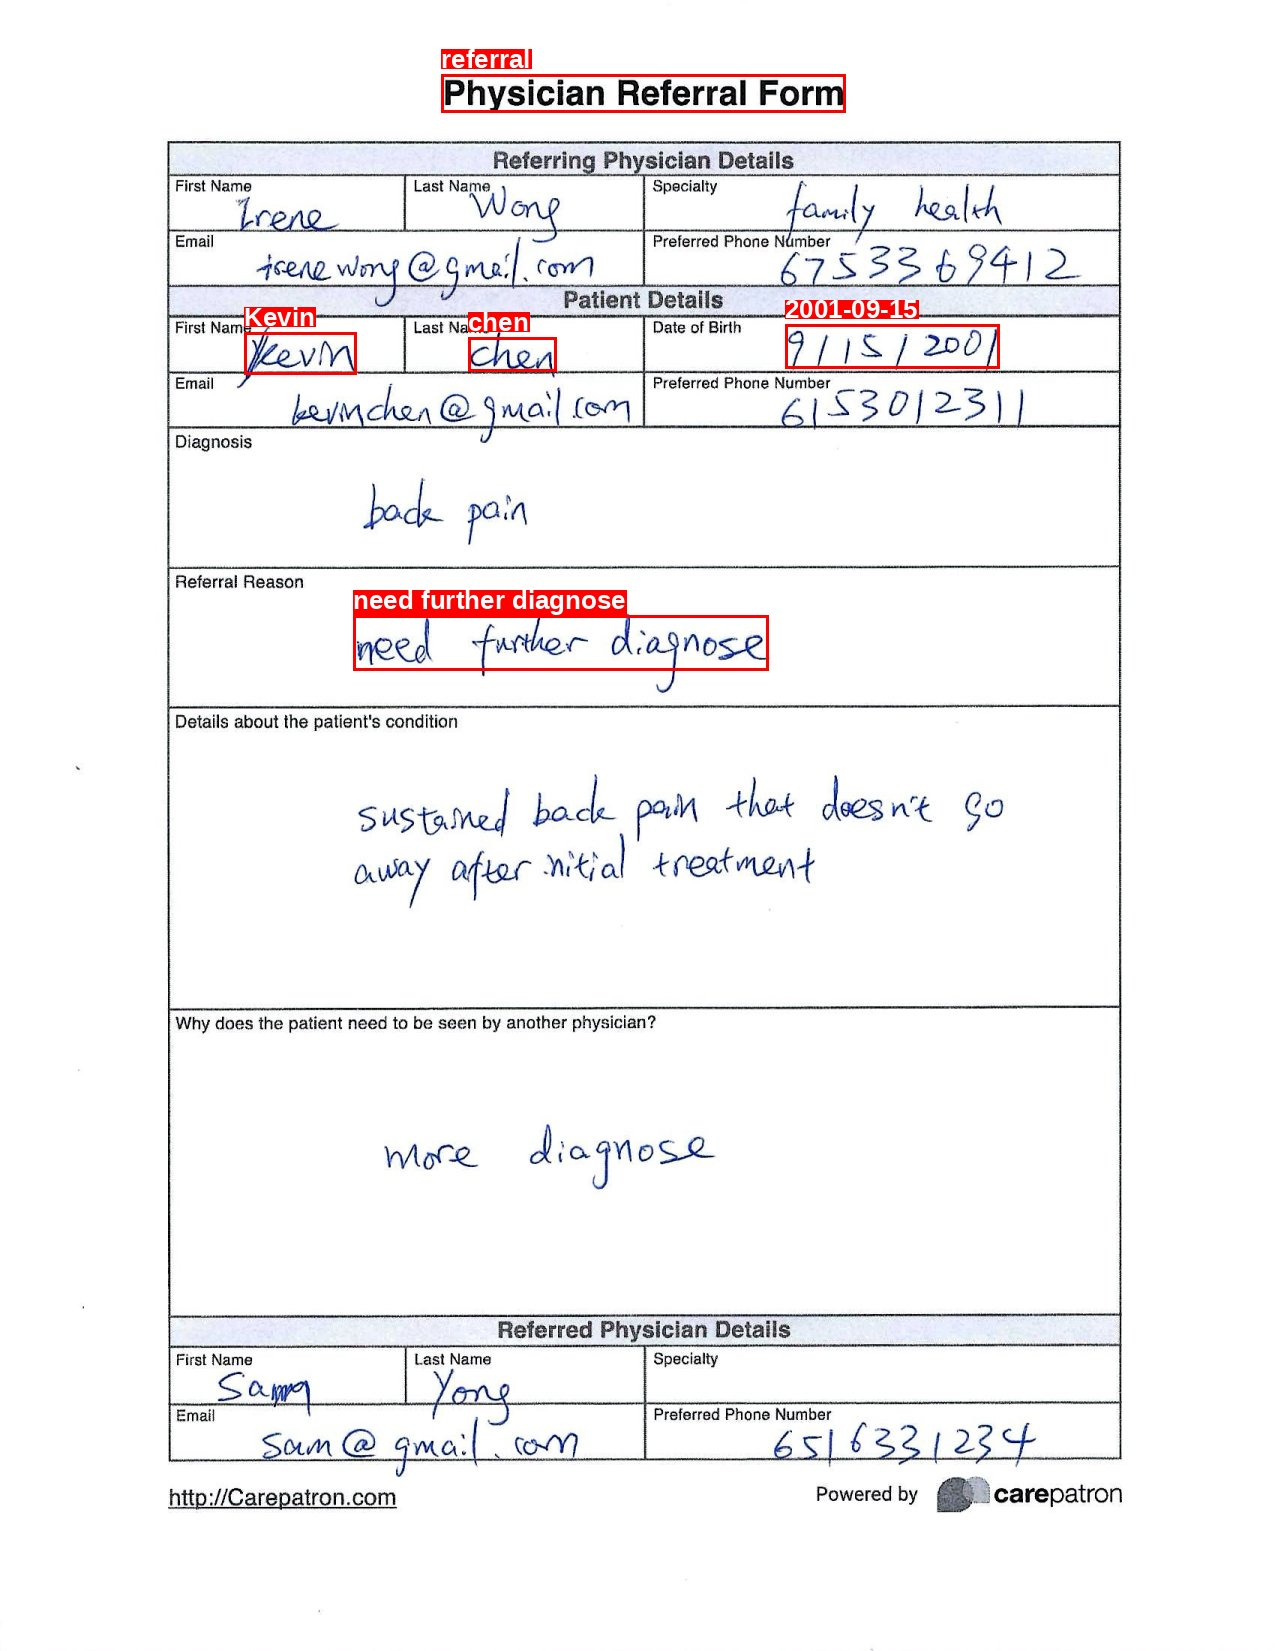

In [11]:
bboxes = collect_bboxes(payload)
pages_with_boxes = sorted({b[1] for b in bboxes})
print(f"Found {len(bboxes)} grounded boxes (schema={document_type!r})")
print(
    "Showing page(s) with extraction grounding: "
    + (", ".join(f"Page {p + 1}" for p in pages_with_boxes) if pages_with_boxes else "(none)")
)
print("Other PDF pages are omitted here. They were not grounded by the selected schema.")

if bboxes:
    render_bboxes(bboxes, pdf_pages, width=500)
else:
    print("No bboxes found. Inspect payload above.")


### 📋 What was extracted

A readable table of each grounded field, its value, and confidence, from whichever schema was selected.


In [12]:
#@title Extraction table helpers { display-mode: "form" }
import re
import pandas as pd
from IPython.display import display


def show_extracted(bboxes):
    """Readable summary: one row per field with its final value and confidence."""
    rows, seen = [], set()
    for field, _page, _xywh, _label, value, conf in bboxes:
        if field in seen:
            continue
        seen.add(field)
        name = re.sub(r"^(?:[^.\[]+\.)*?(?:[^.\[]*\[\d+\]\.)+", "", field)  # drop wrapper + list index
        rows.append({"Field": name, "Value": "" if value is None else str(value), "Confidence": conf})
    df = pd.DataFrame(rows, columns=["Field", "Value", "Confidence"])
    return df.style.hide(axis="index").set_table_styles([
        {"selector": "th, td", "props": [("text-align", "left"), ("padding", "6px 14px"), ("font-size", "13px")]},
        {"selector": "thead th", "props": [("background", "#f1f3f4"), ("font-weight", "600")]},
    ])


print("Extraction table helpers loaded.")


Extraction table helpers loaded.


In [13]:
if bboxes:
    display(show_extracted(bboxes))
else:
    print("Run the bbox cell above first.")


Field,Value,Confidence
patient.givenName,Kevin,hi
patient.familyName,chen,hi
patient.dateOfBirth,2001-09-15,hi
type,referral,hi
reasonForReferral,need further diagnose,hi


---
## 📋 6. Summary

| | Multi-schema extraction (Orion-2) |
|---|---|
| **Call** | `client.agent.execute` (once) |
| **Model** | `vlmrun-orion-2:pro` |
| **Skill** | `medical-multi-schema-extraction` |
| **Schema selection** | Automatic: classify → load `schemas/<documentType>.json` |
| **Grounding & confidence** | Baked into the skill after the schema is selected |
| **Wait** | `executions.wait` |
| **Selection signal** | `schemaUsed` + `documentType` (+ `classificationRationale`) in the response |

**The key points:**

1. You do not choose the schema up front. The skill **selects** it from the classified document type.
2. One execution handles classify + select + grounded extract.
3. The same skill can route other document types (e.g. medical-record request or progress note) to a different schema. This notebook demos the referral schema.
